## 📊 Investigating MSE Sensitivity to Frequency and Amplitude Content in Signals

### 🎯 Objective

To demonstrate that **Mean Squared Error (MSE)** is **more sensitive to differences in high-amplitude, low-frequency** components when comparing signals — even if the high-frequency components match well. Specifically, this experiment explores how MSE favors **high-amplitude low-frequency** content over **high-frequency components** with potentially smaller amplitude.

---

### 🧪 Experiment Setup

We constructed a synthetic **source signal** by summing three sine waves from distinct frequency ranges:

- **Low frequency (2 Hz)** with **high amplitude (5.0)**
- **Mid frequency (15 Hz)** with **moderate amplitude (2.0)**
- **High frequency (100 Hz)** with **low amplitude (0.5)**

This represents a realistic signal where **most energy is concentrated in low frequencies**, but high-frequency content is still present.

```python
source = low_amp * np.sin(2 * np.pi * low_freq * t) +
         mid_amp * np.sin(2 * np.pi * mid_freq * t) +
         high_amp * np.sin(2 * np.pi * high_freq * t)



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Set the sampling rate and duration
fs = 1000  # Sampling frequency in Hz
t = np.linspace(0, 1, fs, endpoint=False)  # 1 second duration

# Frequencies
low_freq = 2     # Hz
mid_freq = 20    # Hz
high_freq = 100  # Hz

# Create a source signal with low, mid, and high frequency components
low_amp = 5
mid_amp = 1
high_amp = 0.5

source = (
    low_amp * np.sin(2 * np.pi * low_freq * t) +
    mid_amp * np.sin(2 * np.pi * mid_freq * t) +
    high_amp * np.sin(2 * np.pi * high_freq * t)
)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


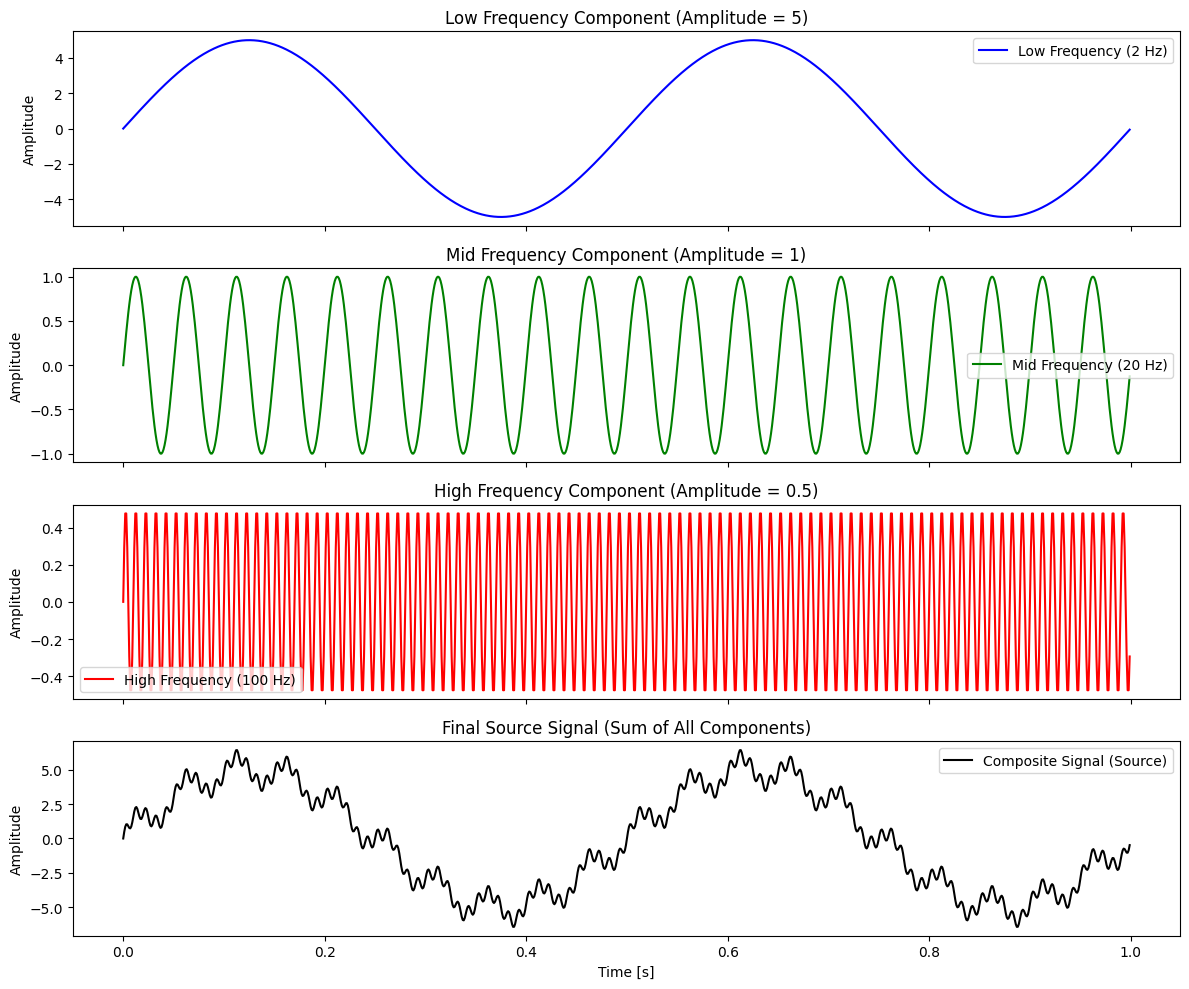

In [7]:
# Recreate components for clarity
low_component = low_amp * np.sin(2 * np.pi * low_freq * t)
mid_component = mid_amp * np.sin(2 * np.pi * mid_freq * t)
high_component = high_amp * np.sin(2 * np.pi * high_freq * t)

# Plot the components of the source signal
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axs[0].plot(t, low_component, label=f'Low Frequency ({low_freq} Hz)', color='blue')
axs[0].set_title(f'Low Frequency Component (Amplitude = {low_amp})')
axs[0].set_ylabel('Amplitude')
axs[0].legend()

axs[1].plot(t, mid_component, label=f'Mid Frequency ({mid_freq} Hz)', color='green')
axs[1].set_title(f'Mid Frequency Component (Amplitude = {mid_amp})')
axs[1].set_ylabel('Amplitude')
axs[1].legend()

axs[2].plot(t, high_component, label=f'High Frequency ({high_freq} Hz)', color='red')
axs[2].set_title(f'High Frequency Component (Amplitude = {high_amp})')
axs[2].set_ylabel('Amplitude')
axs[2].legend()

axs[3].plot(t, source, label='Composite Signal (Source)', color='black')
axs[3].set_title('Final Source Signal (Sum of All Components)')
axs[3].set_xlabel('Time [s]')
axs[3].set_ylabel('Amplitude')
axs[3].legend()

plt.tight_layout()
fig.savefig("source_components.eps", format="eps")
plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


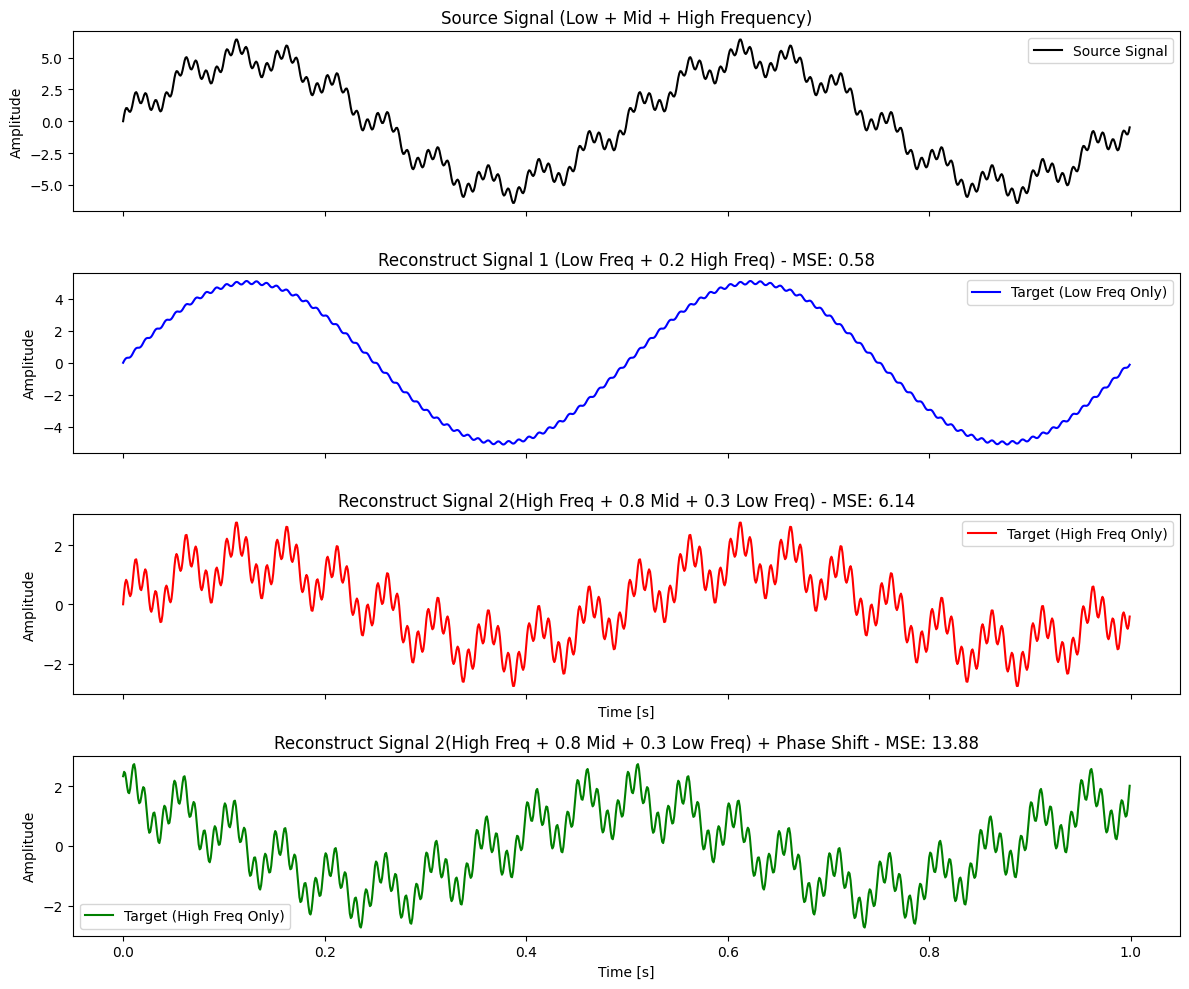

In [9]:

target_low = (
    low_amp * np.sin(2 * np.pi * low_freq * t) +
    0.2 * high_amp * np.sin(2 * np.pi * high_freq * t)
)

# target_mixed_high_v2: mostly high-frequency + a bit of mid-frequency
target_high = (
    high_amp * np.sin(2 * np.pi * high_freq * t) +
    0.8 * mid_amp * np.sin(2 * np.pi * mid_freq * t) +
    0.3 * low_amp * np.sin(2 * np.pi * low_freq * t)
)

target_high_phase = (
    high_amp * np.sin(2 * np.pi * high_freq * t + np.pi/3) +  # Phase shift of π/3
    0.8 * mid_amp * np.sin(2 * np.pi * mid_freq * t + np.pi/6) +  # Phase shift of π/6 
    0.3 * low_amp * np.sin(2 * np.pi * low_freq * t + np.pi/2)  # Phase shift of π/2
)

mse_low = mean_squared_error(source, target_low)
mse_high = mean_squared_error(source, target_high)
mse_high_phase = mean_squared_error(source, target_high_phase)

fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axs[0].plot(t, source, label='Source Signal', color='black')
axs[0].set_title('Source Signal (Low + Mid + High Frequency)')
axs[0].set_ylabel('Amplitude')
axs[0].legend()

axs[1].plot(t, target_low, label='Target (Low Freq Only)', color='blue')
axs[1].set_title(f'Reconstruct Signal 1 (Low Freq + 0.2 High Freq) - MSE: {mse_low:.2f}')
axs[1].set_ylabel('Amplitude')
axs[1].legend()

axs[2].plot(t, target_high, label='Target (High Freq Only)', color='red')
axs[2].set_title(f'Reconstruct Signal 2(High Freq + 0.8 Mid + 0.3 Low Freq) - MSE: {mse_high:.2f}')
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('Amplitude')
axs[2].legend()

axs[3].plot(t, target_high_phase, label='Target (High Freq Only)', color='green')
axs[3].set_title(f'Reconstruct Signal 2(High Freq + 0.8 Mid + 0.3 Low Freq) + Phase Shift - MSE: {mse_high_phase:.2f}')
axs[3].set_xlabel('Time [s]')
axs[3].set_ylabel('Amplitude')
axs[3].legend()

plt.tight_layout()
fig.savefig("synthetic_recons.eps", format="eps")
plt.show()


In [27]:
mse_low = mean_squared_error(source, target_low)
mse_high = mean_squared_error(source, target_high)
print("MSE between Source and Target with Low Frequency Component Only:  ", round(mse_low, 4))
print("MSE between Source and Target with High Frequency Component Only: ", round(mse_high, 4))
print("MSE between Source and Target with High Frequency Component Only: ", round(mse_high_phase, 4))



MSE between Source and Target with Low Frequency Component Only:   0.58
MSE between Source and Target with High Frequency Component Only:  6.145
MSE between Source and Target with High Frequency Component Only:  13.8772


### ✅ Conclusion

This experiment highlights a key limitation of **MSE** as a reconstruction loss for **EEG-X**, where we compare the output of a decoder with rASR-cleaned input.

> **MSE tends to favor reconstructions that preserve high-amplitude low-frequency components (like alpha or some artifacts)**, even if they miss important high-frequency signals like beta, gamma.

This means that the learned representations are more likely to preserve **low-frequency, high-amplitude information**, potentially at the cost of losing critical high-frequency patterns that might carry important cognitive or neural signals.



## 📊 Addressing MSE Sensitivity with a Random Kernel Transformation

### 🎯 Objective

To demonstrate that applying a **random kernel transformation** to the signal before calculating **MSE** can help mitigate the bias towards high-amplitude, low-frequency components. This aims to reduce the effect of low-frequency dominance in the MSE metric when comparing signals.

---

### 🧪 Experiment Setup

We will apply a **random kernel** to the **source signal** and the **target signals** (reconstructions) before calculating the **MSE**. The kernel transformation will randomly affect the frequency content of the signal, potentially allowing for a more balanced comparison across all frequencies, including the high-frequency components.

---

### 🔧 Random Kernel Application

A random kernel can be simulated by applying a **random Fourier transform** or a **random convolution filter**. This transformation will allow us to reduce the influence of low-frequency, high-amplitude components and balance the comparison across different frequency bands.

Here’s how we apply the random kernel:



In [39]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

class HydraGPU(nn.Module):

    def __init__(self, input_length, k = 8, g = 64, seed = None):

        super().__init__()

        if seed is not None:
            torch.manual_seed(seed)

        self.k = k # num kernels per group
        self.g = g # num groups

        max_exponent = np.log2((input_length - 1) / (15 - 1)) # kernel length = 9

        self.dilations = 2 ** torch.arange(int(max_exponent) + 1)
        self.num_dilations = len(self.dilations)

        self.paddings = torch.div((15 - 1) * self.dilations, 2, rounding_mode = "floor").int()

        self.divisor = min(2, self.g)
        self.h = self.g // self.divisor

        W = torch.randn(self.num_dilations, self.divisor, self.k * self.h, 1, 15)
        W = W - W.mean(-1, keepdims = True)
        W = W / W.abs().sum(-1, keepdims = True)

        self.register_buffer("W", W)
        
        # self.num_features_ = self.num_dilations * self.divisor * self.k * self.h * 2
        self.num_features = self.num_dilations * self.divisor * self.k * self.h * 2

    def batch(self, X, batch_size = 256):
        num_examples = X.shape[0]
        if num_examples <= batch_size:
            return self(X)
        else:
            Z = []
            batches = torch.arange(num_examples).split(batch_size)
            for batch in batches:
                Z.append(self(X[batch]))
            return torch.cat(Z)

    def forward(self, X):

        num_examples = X.shape[0]

        if self.divisor > 1:
            diff_X = torch.diff(X)

        Z = []

        for dilation_index in range(self.num_dilations):

            d = self.dilations[dilation_index].item()
            p = self.paddings[dilation_index].item()

            for diff_index in range(self.divisor):

                _Z = F.conv1d(X if diff_index == 0 else diff_X, self.W[dilation_index, diff_index], dilation = d, padding = p) \
                      .view(num_examples, self.h, self.k, -1)

                max_values, max_indices = _Z.max(2)
                count_max = torch.zeros(num_examples, self.h, self.k, device = X.device)

                min_values, min_indices = _Z.min(2)
                count_min = torch.zeros(num_examples, self.h, self.k, device = X.device)

                count_max.scatter_add_(-1, max_indices, max_values)
                count_min.scatter_add_(-1, min_indices, torch.ones_like(min_values))

                Z.append(count_max)
                Z.append(count_min)

        Z = torch.cat(Z, 1).view(num_examples, -1)

        # return Z
        return Z.clamp(0).sqrt()

In [40]:
transform = HydraGPU(1000)

In [41]:
source_hydra = transform(torch.tensor(source, dtype=torch.float32).unsqueeze(0))
target_low_hydra = transform(torch.tensor(target_low, dtype=torch.float32).unsqueeze(0))
target_high_hydra = transform(torch.tensor(target_high, dtype=torch.float32).unsqueeze(0))
target_high_phase_hydra = transform(torch.tensor(target_high_phase, dtype=torch.float32).unsqueeze(0))

mse_low_hydra = mean_squared_error(source_hydra, target_low_hydra)
mse_high_hydra = mean_squared_error(source_hydra, target_high_hydra)
mse_high_phase_hydra = mean_squared_error(source_hydra, target_high_phase_hydra)
print(f"MSE After Multiple Kernel Transformation - Low-Frequency Dominant Target: {mse_low_hydra:.4f}")
print(f"MSE After Multiple Kernel Transformation - High-Frequency Dominant Target: {mse_high_hydra:.4f}")
print(f"MSE After Multiple Kernel Transformation - High-Frequency Dominant + Phase Shift Target: {mse_high_phase_hydra:.4f}")

MSE After Multiple Kernel Transformation - Low-Frequency Dominant Target: 9.2575
MSE After Multiple Kernel Transformation - High-Frequency Dominant Target: 6.7419
MSE After Multiple Kernel Transformation - High-Frequency Dominant + Phase Shift Target: 7.2516


In [42]:
source_hydra.shape


torch.Size([1, 7168])

In [44]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

class HydraMultivariateGPU(nn.Module):

    def __init__(self, input_length, num_channels, k = 8, g = 64, max_num_channels = 8, seed = None):

        super().__init__()

        if seed is not None:
            torch.manual_seed(seed)

        self.k = k # num kernels per group
        self.g = g # num groups

        max_exponent = np.log2((input_length - 1) / (9 - 1)) # kernel length = 9

        self.dilations = 2 ** torch.arange(int(max_exponent) + 1)
        self.num_dilations = len(self.dilations)

        self.paddings = torch.div((9 - 1) * self.dilations, 2, rounding_mode = "floor").int()

        self.divisor = min(2, self.g)
        self.h = self.g // self.divisor

        W = torch.randn(self.num_dilations, self.divisor, self.k * self.h, 1, 9)
        W = W - W.mean(-1, keepdims = True)
        W = W / W.abs().sum(-1, keepdims = True)

        self.register_buffer("W", W)

        # self.num_features_ = self.num_dilations * self.divisor * self.k * self.h * 2
        self.num_features = self.num_dilations * self.divisor * self.k * self.h * 2

        num_channels_per = np.clip(num_channels // 2, 2, max_num_channels)
        self.I = torch.randint(0, num_channels, (self.num_dilations, self.divisor, self.h, num_channels_per))

    def batch(self, X, batch_size = 256):
        num_examples = X.shape[0]
        if num_examples <= batch_size:
            return self(X)
        else:
            Z = []
            batches = torch.arange(num_examples).split(batch_size)
            for batch in batches:
                Z.append(self(X[batch]))
            return torch.cat(Z)

    def forward(self, X):

        num_examples = X.shape[0]

        if self.divisor > 1:
            diff_X = torch.diff(X)

        Z = []

        for dilation_index in range(self.num_dilations):

            d = self.dilations[dilation_index].item()
            p = self.paddings[dilation_index].item()

            for diff_index in range(self.divisor):

                _Z = F.conv1d(X[:, self.I[dilation_index, diff_index]].sum(2) if diff_index == 0 else diff_X[:, self.I[dilation_index, diff_index]].sum(2),
                              self.W[dilation_index, diff_index], dilation = d, padding = p,
                              groups = self.h) \
                      .view(num_examples, self.h, self.k, -1)

                max_values, max_indices = _Z.max(2)
                count_max = torch.zeros(num_examples, self.h, self.k, device = X.device)

                min_values, min_indices = _Z.min(2)
                count_min = torch.zeros(num_examples, self.h, self.k, device = X.device)

                count_max.scatter_add_(-1, max_indices, max_values)
                count_min.scatter_add_(-1, min_indices, torch.ones_like(min_values))

                Z.append(count_max)
                Z.append(count_min)

        Z = torch.cat(Z, 1).view(num_examples, -1)

        return Z.clamp(0).sqrt()

In [52]:
# Create a random 3D tensor of size (10, 14, 256)
tensor_3d = torch.randn(10, 1, 256)
transform = HydraMultivariateGPU(256,1)

In [53]:
X_training_transform = transform(tensor_3d)
X_training_transform.shape

torch.Size([10, 5120])